In [1]:
# All imports go here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pprint import pprint
from typing import Optional

In [2]:
# All useful constants go here
TRAIN_FILE = 'dataset/train.csv'
TEST_FILE = 'dataset/test.csv'

TRAIN_SAMPLES = None
TEST_SAMPLES = 10000

In [3]:
def read_bonus_malus(val: str, m_value: int = -1) -> Optional[int]:
    val_str = val.strip().upper()
    if val_str == 'M':
        return m_value
    try:
        return int(float(val_str))
    except:
        return None

def read_car_year(val: str, first_year=1900, last_year=2026) -> Optional[int]:
    val_str = val.replace('\xa0', '').strip()
    try:
        val_int = int(float(val_str))
        if val_int < first_year or val_int > last_year:
            return None
        return val_int
    except:
        return None

In [4]:
def load_dataset(path, nrows = None):
    df = pd.read_csv(path, nrows=nrows, 
                     converters={'bonus_malus': read_bonus_malus, 'car_year': read_car_year})
    
    # Pandas already have unique index
    assert df['unique_id'].nunique() == df.shape[0], f"{df['unique_id'].nunique()} != {df.shape[0]}"
    df.drop(columns="unique_id", inplace=True)

    # If no driver IIN just drop ???
    # We can also assume that this is new driver 
    df.dropna(subset=['driver_iin'], inplace=True)

    # Some numericals, that we can fill with zeros (probably)
    df.fillna({
        'claim_cnt': 0,
        'claim_amount': 0,
        'ownerkato_short': 0,
        'car_year': 0,
        'engine_volume': 0,
        'engine_power': 0,
    }, inplace=True)
    
    return df

In [5]:
def remove_scores(df: pd.DataFrame) -> pd.DataFrame:
    score_cols_mask = df.columns.str.startswith('SCORE')
    return df.loc[:,~score_cols_mask]

In [6]:
def prepare_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Assume short KATO is enough (or drop short instead)
    df.drop(columns=['ownerkato'], inplace=True)

    # Drop name columns
    df.drop(columns=[
        'is_individual_person_name', 
        'is_residence_name', 
        'region_name', 
        'age_experience_name', 
        'vehicle_type_name'
    ], inplace=True)
    
    # Drop model of car (or drop mark instead)
    df.drop(columns=['model'], inplace=True)

    # New features
    # How many percent of premium we actually get
    df['term'] = (df['premium_wo_term'] / df['premium']) * 100

    return df

In [7]:
def check_dataset(df: pd.DataFrame, train=True):
    count_df = df.groupby(['contract_number', 'driver_iin', 'car_number']).size().reset_index().rename(columns={0:'count'})
    non_unique = count_df[count_df['count'] > 1]
    assert non_unique.size == 0, f"(policy, driver, car) is unique for each row"

    if train:
        result = df.groupby('contract_number')['claim_cnt'].nunique() <= 1
        assert result.all(), "Claim count is unique for policy"
    
        result = df.groupby('contract_number')['is_claim'].nunique() <= 1
        assert result.all(), "isClaim is unique for policy"

    result = df.groupby(['contract_number', 'driver_iin'])['bonus_malus'].nunique() <= 1
    assert result.all(), "Bonus malus is unique for (policy, driver)"

In [8]:
# Loss Ratio Calculation (Коэффициент выплат)
def loss_ratio(df: pd.DataFrame) -> float:
    total_claims = df['claim_amount'].sum()
    total_premium = df['premium_wo_term'].sum()
    loss_ratio = (total_claims / total_premium) * 100 if total_premium != 0 else 0
    return loss_ratio

In [9]:
def just_increase(premium: float) -> float:
    return 3 * premium

In [10]:
# Load datasets
train_dfs = {}
test_dfs = {}

train_dfs['main'] = load_dataset(TRAIN_FILE, nrows=TRAIN_SAMPLES)
test_dfs['main'] = load_dataset(TEST_FILE, nrows=TEST_SAMPLES)

check_dataset(train_dfs['main'])
check_dataset(test_dfs['main'], train=False)

In [11]:
train_dfs['prepared'] = prepare_dataset(remove_scores(train_dfs['main']))
test_dfs['prepared'] = prepare_dataset(remove_scores(test_dfs['main']))

In [12]:
# Per policy table
train_dfs['policy'] = train_dfs['prepared'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
    'claim_amount': 'first',
    'claim_cnt': 'first',
    'is_claim': 'first',
    'term': 'first',
    "experience_year": "mean",
    "car_year": "mean",
    "bonus_malus": "mean",
    "engine_power": "mean",
    "driver_iin": "nunique",
    "car_number": "nunique"
}).rename(columns={
    "driver_iin": "n_drivers",
    "car_number": "n_cars"
}).reset_index()

test_dfs['policy'] = test_dfs['main'].groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
}).reset_index()
mean_train_claim = train_dfs['policy']['claim_amount'].mean()
test_dfs['policy']['claim_amount'] = mean_train_claim

train_loss_ratio = loss_ratio(train_dfs['policy'])
test_loss_ratio = loss_ratio(test_dfs['policy'])
print(f"Train Loss Ratio: {train_loss_ratio:.2f}%")
print(f"Test Loss Ratio: {test_loss_ratio:.2f}%")
print(f"Mean train claim amount: {mean_train_claim:2f}")

Train Loss Ratio: 123.43%
Test Loss Ratio: 145.20%
Mean train claim amount: 13137.173331


In [13]:
train_after = train_dfs['policy'].copy()
k = train_loss_ratio / 70
train_after['premium'] = train_dfs['policy']['premium'].map(lambda p: k * p)
train_after['premium_wo_term'] = train_after['premium'] * (train_after['term'] / 100)

train_loss_ratio = loss_ratio(train_after)
print(f"Coefficient: {k:.2f}")
print(f"After Train Loss Ratio: {train_loss_ratio:.2f}%")

Coefficient: 1.76
After Train Loss Ratio: 70.00%


In [16]:
tp = train_dfs['policy']
print(list(tp.columns))
tp.sort_values('premium', ascending=False).head(10)

['contract_number', 'premium', 'premium_wo_term', 'claim_amount', 'claim_cnt', 'is_claim', 'term', 'experience_year', 'car_year', 'bonus_malus', 'engine_power', 'n_drivers', 'n_cars']


,contract_number,premium,premium_wo_term,claim_amount,claim_cnt,is_claim,term,experience_year,car_year,bonus_malus,engine_power,n_drivers,n_cars
167126,ed3d78c0ac45371f6a01b7638b26eed3d39a5989fcc65c...,116896.0,116896.0,686357.0,1.0,1,100.000000,5.500000,2006.0,7.000000,70.0,2,1
60709,564e567f06f36c22666c4348e85f91c05b7e1aca17b330...,87624.0,6918.0,0.0,0.0,0,7.895097,4.500000,2012.0,4.000000,385.0,2,1
75228,6ad6d6083055b95dbe8d122f2ea68dcc2cc9d454f410c1...,87624.0,87624.0,0.0,0.0,0,100.000000,9.666667,2012.0,7.000000,385.0,3,1
125519,b21545a8df87a086642d1ef9c0fbea0c1badd59628ba77...,79188.0,79188.0,0.0,0.0,0,100.000000,3.000000,2012.0,6.000000,228.0,2,1
171948,f407b62bb55776f7e2026e22bee2bbfa4970a0e235a0ce...,75721.0,35682.0,0.0,0.0,0,47.122991,0.000000,1995.0,1.500000,71.0,2,1
70857,64b480b6c7343681cb8b3caa56d18e630605a0e9fce0f4...,75417.0,51242.0,0.0,0.0,0,67.944893,12.333333,1984.0,9.666667,96.0,3,1
31033,2be910f52aa266cf2a1db2c2b6585ab95a72eb5efeadb2...,75417.0,75417.0,0.0,0.0,0,100.000000,4.666667,1993.0,9.333333,160.0,3,1
62001,581b4ec888820499c3f542a2df9b7df74779afe5b698c8...,75228.0,75228.0,0.0,0.0,0,100.000000,4.400000,2002.0,8.800000,361.0,5,1
77085,6d618fad334a5c25c69f6d07b89e4c659a10eb7b62c623...,75228.0,75228.0,113442.0,1.0,1,100.000000,6.285714,2004.0,9.857143,206.0,7,1
80742,727c113dbebaa15823a903e539bc3b6d47538ebc95ccc8...,75228.0,9481.0,0.0,0.0,0,12.603020,7.000000,2007.0,8.800000,247.0,5,1


In [31]:
from sklearn.model_selection import train_test_split

X = train_dfs['policy'].drop(columns=[
    "contract_number",
    "premium_wo_term",
    "term",
    "claim_amount",
    "claim_cnt",
    "is_claim"
])

X.fillna(0, inplace=True)

y = train_dfs['policy']["is_claim"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X.columns, X_train.shape, X_valid.shape)

Index(['premium', 'experience_year', 'car_year', 'bonus_malus', 'engine_power',
       'n_drivers', 'n_cars'],
      dtype='str') (144427, 7) (36107, 7)


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [34]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

proba = model.predict_proba(X_valid)[:,1]
auc = roc_auc_score(y_valid, proba)

pred = (proba > 0.5).astype(int)
f1 = f1_score(y_valid, pred)

print("AUC:", auc)
print("F1:", f1)
tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel().tolist()
print(f"TP = {tp}, FP = {fp}\nFN = {fn}, TN = {tn}")

AUC: 0.6541154541828568
F1: 0.06254062251751281
TP = 433, FP = 12692
FN = 289, TN = 22693


In [43]:
full_proba = model.predict_proba(X)[:,1]
train_dfs['policy']["expected_loss"] = full_proba * mean_train_claim * 2
train_dfs['policy']["new_premium"] = train_dfs['policy']["expected_loss"] / 0.7
train_dfs['policy']["new_premium"] = train_dfs['policy']["new_premium"].clip(
    lower=train_dfs['policy']["premium"] * 0,
    upper=train_dfs['policy']["premium"] * 3
)

loss_r = (train_dfs['policy']["claim_amount"].sum() / train_dfs['policy']["new_premium"].sum() * 100)
print(f"Loss ratio = {loss_r:.2f}%")

train_dfs['policy'].sort_values('expected_loss', ascending=False).head(10)

Loss ratio = 75.17%


,contract_number,premium,premium_wo_term,claim_amount,claim_cnt,is_claim,term,experience_year,car_year,bonus_malus,engine_power,n_drivers,n_cars,expected_loss,new_premium
167126,ed3d78c0ac45371f6a01b7638b26eed3d39a5989fcc65c...,116896.0,116896.0,686357.0,1.0,1,100.000000,5.500000,2006.0,7.000000,70.0,2,1,26098.871365,37284.101950
171948,f407b62bb55776f7e2026e22bee2bbfa4970a0e235a0ce...,75721.0,35682.0,0.0,0.0,0,47.122991,0.000000,1995.0,1.500000,71.0,2,1,25679.590282,36685.128975
60709,564e567f06f36c22666c4348e85f91c05b7e1aca17b330...,87624.0,6918.0,0.0,0.0,0,7.895097,4.500000,2012.0,4.000000,385.0,2,1,25496.385768,36423.408240
112324,9f235f1bcd1a1e7c6637a14799ef53853115b2dbf232c8...,67700.0,67700.0,0.0,0.0,0,100.000000,0.000000,2011.0,2.000000,110.0,2,1,25337.901236,36197.001765
125519,b21545a8df87a086642d1ef9c0fbea0c1badd59628ba77...,79188.0,79188.0,0.0,0.0,0,100.000000,3.000000,2012.0,6.000000,228.0,2,1,25234.521562,36049.316517
46626,4224ad0a0453c35345fc3113888ad67cb446bc46712ea1...,61813.0,61813.0,0.0,0.0,0,100.000000,1.000000,2008.0,3.000000,0.0,1,1,25149.556244,35927.937491
75228,6ad6d6083055b95dbe8d122f2ea68dcc2cc9d454f410c1...,87624.0,87624.0,0.0,0.0,0,100.000000,9.666667,2012.0,7.000000,385.0,3,1,25121.684161,35888.120230
166548,ec69954567f423dc8d2805c286bc430203cd111104f4c5...,61385.0,61385.0,0.0,0.0,0,100.000000,1.500000,1991.0,2.000000,44.0,2,1,25119.073855,35884.391222
36074,33173e2d7a6411c7a02bb9aca584248b45f254624ddb79...,67524.0,67524.0,0.0,0.0,0,100.000000,2.333333,2007.0,4.666667,74.0,3,1,25055.263742,35793.233918
166878,ecec4aef9e990faf9667065aca63484e75b6cf6fddc593...,67524.0,67524.0,0.0,0.0,0,100.000000,2.333333,2005.0,4.666667,76.0,3,1,25050.656525,35786.652178


In [17]:
df = train_dfs['main']
policy_car = df[["contract_number", "car_number", "mark", "claim_cnt"]].drop_duplicates()
cars_per_policy = policy_car.groupby("contract_number")["car_number"].nunique().reset_index(name="n_cars")
policy_car = policy_car.merge(cars_per_policy, on="contract_number")
policy_car["claim_share"] = (
    policy_car["claim_cnt"] / policy_car["n_cars"]
)
car_claims = (
    policy_car
    .groupby("car_number").agg({
        "mark": 'first',
        "claim_share": "sum",
        "n_cars": lambda _: 1,
    })
    .reset_index()
)

s = car_claims.groupby('mark')[["claim_share", "n_cars"]].sum()
s['crash_prob'] = (s['claim_share'] / s['n_cars']) * 100
s[s['n_cars'] > 10].sort_values('crash_prob', ascending=False)

,claim_share,n_cars,crash_prob
mark,,,
ГАЗ-330252,4.0,27,14.814815
ГАЗ-3302,1.0,11,9.090909
LADA\t\t,1.0,12,8.333333
SCHWARZMUELLER,1.0,12,8.333333
HUMMER,3.0,39,7.692308
...,...,...,...
ОДАЗ,0.0,33,0.000000
СЗАП,0.0,27,0.000000
САЗ,0.0,31,0.000000


In [254]:
train_dfs['car'] = train_dfs['main'].groupby('car_number').agg({
    'mark': 'first',
    'model': 'first',
}).reset_index()

tc = train_dfs['car']
tc.shape

(21123, 3)

Text(0.5, 1.0, 'Claim vs No-Claim (Policy Count)')

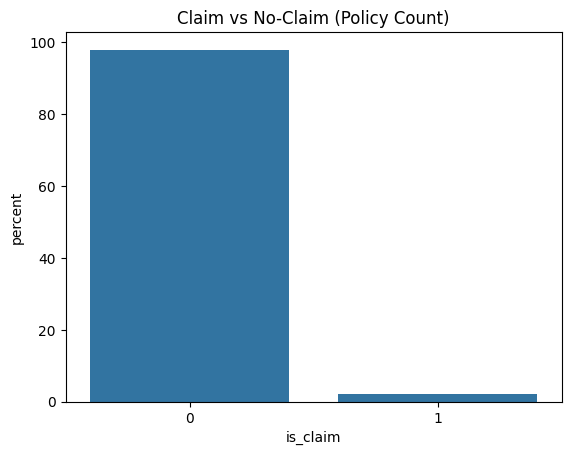

In [9]:
# Fancy plots go here

sns.countplot(x='is_claim', data=policy_df, stat='percent')
plt.title('Claim vs No-Claim (Policy Count)')

plt.figure(figsize=(57, 10))
train_df.groupby('car_year')['is_claim'].count().plot.bar()
plt.ylabel("Кол-во проишествий")
plt.xlabel("Год авто")

In [11]:
for column in train_df.columns:
    if column.endswith('_name'):
        print(column + ":")
        pprint(list(train_df[column].unique()))
        print()

is_individual_person_name:
['Физ. лицо']

is_residence_name:
['Резидент', 'Не резидент']

region_name:
['01 Алматинская область',
 '18 Туркестанская область',
 '14 Мангистауская область',
 '17 Шымкент',
 '12 Кызылординская область',
 '05 Карагандинская область',
 '15 Алматы',
 '09 Жамбылская область',
 '07 Акмолинская область',
 '16 Астана',
 '13 Атырауская область',
 '10 Актюбинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '08 Павлодарская область',
 '11 Западно-Казахстанская область',
 '06 Северо-Казахстанская область',
 'Временная регистрация',
 'Временный въезд']

age_experience_name:
['старше 25 лет/стаж вождения более 2 лет',
 'старше 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения более 2 лет']

vehicle_type_name:
['Легковые',
 'Прицепы(полуприцепы)',
 'Грузовые',
 'Мототранспорт',
 'Автобусы > 16 п.м.',
 'Автобусы до 16 п.м.']



In [15]:
total_claims = train_df.groupby('mark')['is_claim'].sum()
stats = pd.concat([train_df['mark'].value_counts(), total_claims], axis=1)
stats.columns = ['total_cars', 'total_accidents']
stats['accident_rate'] = stats['total_accidents'] / stats['total_cars']
stats

,total_cars,total_accidents,accident_rate
mark,,,
TOYOTA,19437,384,0.019756
HYUNDAI,7241,135,0.018644
VOLKSWAGEN,6412,129,0.020119
MERCEDES-BENZ,5149,59,0.011459
LADA,5077,102,0.020091
...,...,...,...
CF650-2,1,0,0.000000
CA1010A1,1,0,0.000000
ПЛ,1,0,0.000000


In [16]:
train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])
train_df[['accident_rate_by_mark']].head()

/tmp/ipykernel_28490/4213722452.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])


,accident_rate_by_mark
0,0.018644
1,0.020091
2,0.014778
3,0.019756
4,0.018606
